<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/53_SyntheticControl_TSLA_SP500_inclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Synthetic Control 실습: TSLA S&P 500 편입의 반사실 경로
## Synthetic Control — Bilingual Inference Version

### 학습 목표
1. 여러 donor 시계열의 가중합으로 synthetic control을 구성한다.
2. 사전 적합(pre-fit)의 중요성을 이해한다.
3. 개입 이후 처리군과 synthetic control의 gap을 측정한다.
4. donor weight를 해석한다.
5. 결과를 영어와 한글로 모두 출력한다.

### 연구 질문
**TSLA가 S&P 500에 편입되지 않았다면 주가 경로는 어떻게 되었을까?**

## 1. 기본 아이디어

\[
Y_t^{Synthetic}
=
\sum_{j=1}^{J} w_jY_{jt}
\]

단,

\[
w_j \ge 0,\qquad \sum_{j=1}^{J}w_j=1
\]

가중치 \(w_j\)는 개입 이전(pre-treatment) 기간에서  
TSLA와 synthetic TSLA 간 오차가 최소가 되도록 선택합니다.

## 2. 라이브러리 준비

In [1]:
# ============================================================
# STEP 1. Import libraries
# ============================================================

# !pip install -q yfinance pandas numpy matplotlib scipy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("Libraries loaded successfully.")
print("라이브러리를 정상적으로 불러왔습니다.")

Libraries loaded successfully.
라이브러리를 정상적으로 불러왔습니다.


## 3. 처리군과 donor pool 설정

- 처리군: TSLA
- donor pool: GM, F, TM, HMC, STLA
- 이벤트: S&P 500 편입

In [2]:
# ============================================================
# STEP 2. Analysis configuration
# ============================================================

treated = "TSLA"
donors = ["GM", "F", "TM", "HMC", "STLA"]
tickers = [treated] + donors

start = "2020-01-01"
end = "2021-06-30"
event_date = pd.to_datetime("2020-12-21")

print("Treated / 처리군:", treated)
print("Donor pool / 도너 풀:", donors)
print("Event date / 이벤트 일자:", event_date.date())

Treated / 처리군: TSLA
Donor pool / 도너 풀: ['GM', 'F', 'TM', 'HMC', 'STLA']
Event date / 이벤트 일자: 2020-12-21


## 4. 가격 데이터 수집 및 지수화

모든 종목을 시작시점 100으로 지수화하여 상대적 경로를 비교합니다.

In [3]:
# ============================================================
# STEP 3. Download and normalize prices
# ============================================================

prices = {}

for ticker in tickers:
    tmp = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = [col[0] for col in tmp.columns]

    prices[ticker] = tmp["Close"]

px = pd.DataFrame(prices).dropna().copy()

# 시작값을 100으로 지수화
px = px / px.iloc[0] * 100

print("Normalized price panel / 지수화 가격 패널")
display(px.head())

Normalized price panel / 지수화 가격 패널


,TSLA,GM,F,TM,HMC,STLA
Date,,,,,,
2020-01-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2020-01-03,102.963326,97.164279,97.770720,98.952459,98.219265,96.087539
2020-01-06,104.945847,95.880162,97.239927,98.966527,97.939914,95.822283
2020-01-07,109.017801,94.034238,98.195341,99.486763,98.498591,94.098137
2020-01-08,114.382003,92.696645,98.195341,99.240713,98.219265,94.496026


## 5. 사전기간에서 최적 가중치 추정

목표는 TSLA의 사전 경로와 donor 가중합의 평균제곱오차(MSE)를 최소화하는 것입니다.

In [4]:
# ============================================================
# STEP 4. Estimate donor weights
# ============================================================

pre_mask = px.index < event_date

X1 = px.loc[pre_mask, treated].values
X0 = px.loc[pre_mask, donors].values

def objective(weights):
    synthetic = X0 @ weights
    return np.mean((X1 - synthetic) ** 2)

n_donors = len(donors)

# 초기값: 동일가중
w0 = np.ones(n_donors) / n_donors

# 각 가중치는 0~1
bounds = [(0, 1)] * n_donors

# 가중치 합은 1
constraints = [
    {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }
]

result = minimize(
    objective,
    w0,
    bounds=bounds,
    constraints=constraints
)

if not result.success:
    raise RuntimeError(
        f"Optimization failed: {result.message}"
    )

w_hat = result.x

weights = pd.Series(
    w_hat,
    index=donors,
    name="Weight"
).sort_values(ascending=False)

print("Estimated donor weights / 추정 도너 가중치")
display(weights.to_frame())

Estimated donor weights / 추정 도너 가중치


,Weight
TM,1.000000
GM,0.000000
STLA,0.000000
F,0.000000
HMC,0.000000


## 6. Synthetic TSLA와 treatment gap 계산

In [5]:
# ============================================================
# STEP 5. Construct synthetic series and treatment gap
# ============================================================

px["Synthetic_TSLA"] = px[donors].values @ w_hat

# 처리군 - synthetic control
px["Gap"] = (
    px[treated]
    - px["Synthetic_TSLA"]
)

# 사전 RMSE
pre_gap = px.loc[px.index < event_date, "Gap"]
pre_rmse = np.sqrt(np.mean(pre_gap ** 2))

# 사후 평균 gap
post_gap = px.loc[px.index >= event_date, "Gap"]
post_mean_gap = post_gap.mean()

# 사후 평균 절대 gap
post_mean_abs_gap = post_gap.abs().mean()

print(f"Pre-treatment RMSE / 사전 RMSE: {pre_rmse:.6f}")
print(f"Post-treatment mean gap / 사후 평균 gap: {post_mean_gap:.6f}")
print(f"Post-treatment mean absolute gap / 사후 평균 절대 gap: {post_mean_abs_gap:.6f}")

Pre-treatment RMSE / 사전 RMSE: 290.332417
Post-treatment mean gap / 사후 평균 gap: 697.554924
Post-treatment mean absolute gap / 사후 평균 절대 gap: 697.554924


## 7. 실제 TSLA와 Synthetic TSLA 비교

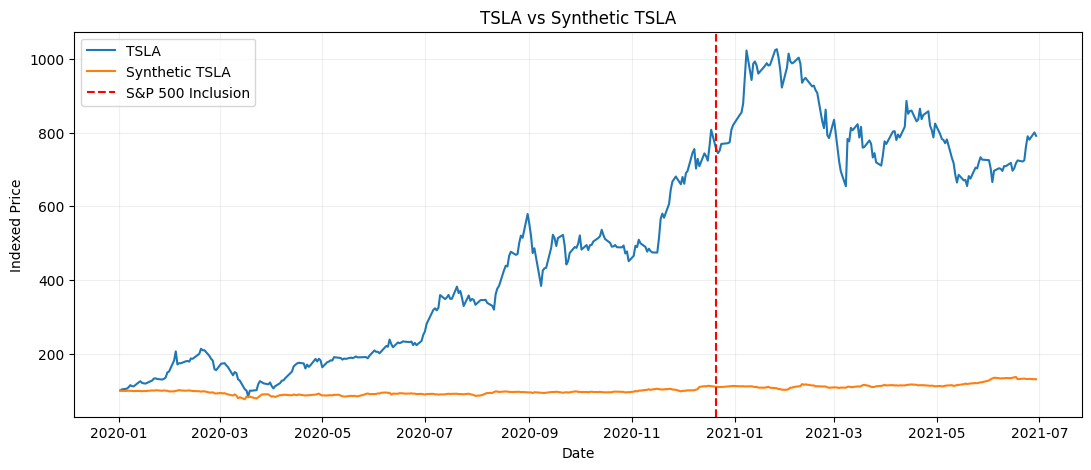

In [6]:
# ============================================================
# STEP 6. Plot treated vs synthetic
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    px.index,
    px[treated],
    label="TSLA",
    linewidth=1.5
)

plt.plot(
    px.index,
    px["Synthetic_TSLA"],
    label="Synthetic TSLA",
    linewidth=1.5
)

plt.axvline(
    event_date,
    color="red",
    linestyle="--",
    label="S&P 500 Inclusion"
)

plt.title("TSLA vs Synthetic TSLA")
plt.xlabel("Date")
plt.ylabel("Indexed Price")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. Treatment gap 시각화

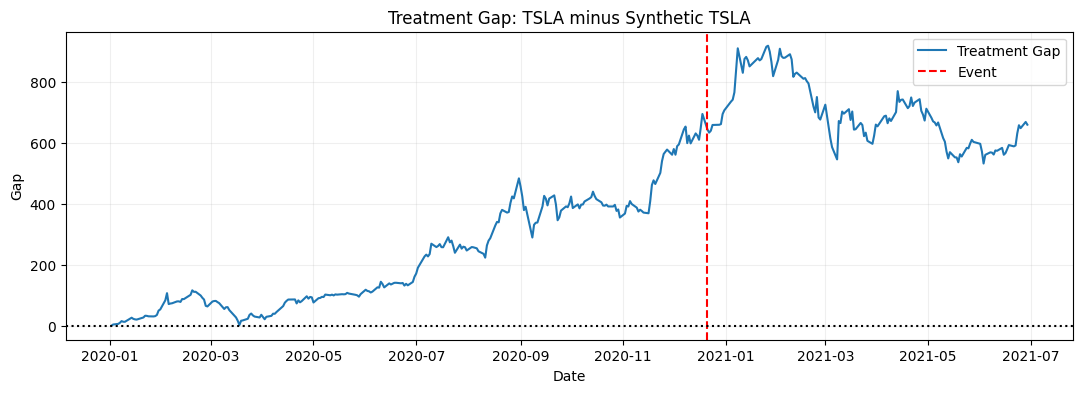

In [7]:
# ============================================================
# STEP 7. Plot treatment gap
# ============================================================

plt.figure(figsize=(13, 4))

plt.plot(
    px.index,
    px["Gap"],
    label="Treatment Gap"
)

plt.axvline(
    event_date,
    color="red",
    linestyle="--",
    label="Event"
)

plt.axhline(
    0,
    color="black",
    linestyle=":"
)

plt.title("Treatment Gap: TSLA minus Synthetic TSLA")
plt.xlabel("Date")
plt.ylabel("Gap")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 9. donor weight 시각화

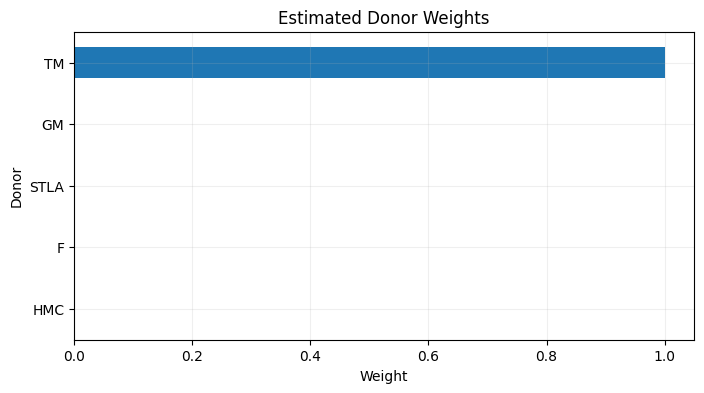

In [8]:
# ============================================================
# STEP 8. Plot donor weights
# ============================================================

plt.figure(figsize=(8, 4))

weights.sort_values().plot(
    kind="barh"
)

plt.title("Estimated Donor Weights")
plt.xlabel("Weight")
plt.ylabel("Donor")
plt.grid(alpha=0.2)
plt.show()

## 10. 영어 + 한글 Synthetic Control 자동 추론 함수

In [9]:
# ============================================================
# STEP 9. Bilingual synthetic control inference
# ============================================================

def bilingual_synth_inference(
    pre_rmse,
    post_mean_gap,
    post_mean_abs_gap,
    weights,
    rmse_threshold=10.0
):
    print("=" * 90)
    print("SYNTHETIC CONTROL INFERENCE REPORT / SYNTHETIC CONTROL 추론 결과")
    print("=" * 90)

    print(f"Pre-treatment RMSE / 사전 RMSE: {pre_rmse:.6f}")
    print(f"Post-treatment mean gap / 사후 평균 gap: {post_mean_gap:.6f}")
    print(
        f"Post-treatment mean absolute gap / 사후 평균 절대 gap: "
        f"{post_mean_abs_gap:.6f}"
    )

    print("\nDonor Weights / 도너 가중치")
    display(weights.to_frame())

    # 사전 적합도
    if pre_rmse <= rmse_threshold:
        en_fit = (
            "The pre-treatment fit is reasonably good, "
            "so the post-treatment gap is more interpretable."
        )
        ko_fit = (
            "개입 이전 적합도가 비교적 양호하므로, "
            "개입 이후 gap을 상대적으로 더 해석할 수 있습니다."
        )
    else:
        en_fit = (
            "The pre-treatment fit is weak. "
            "The post-treatment gap should therefore be interpreted cautiously."
        )
        ko_fit = (
            "개입 이전 적합도가 충분히 좋지 않습니다. "
            "따라서 개입 이후 gap 해석에 주의가 필요합니다."
        )

    # 사후 효과 방향
    if post_mean_gap > 0:
        en_gap = (
            "After the intervention, TSLA stayed on average above "
            "its synthetic counterfactual."
        )
        ko_gap = (
            "개입 이후 TSLA는 평균적으로 synthetic counterfactual보다 "
            "높은 경로를 보였습니다."
        )
    elif post_mean_gap < 0:
        en_gap = (
            "After the intervention, TSLA stayed on average below "
            "its synthetic counterfactual."
        )
        ko_gap = (
            "개입 이후 TSLA는 평균적으로 synthetic counterfactual보다 "
            "낮은 경로를 보였습니다."
        )
    else:
        en_gap = "The average post-treatment gap is approximately zero."
        ko_gap = "개입 이후 평균 gap은 거의 0에 가깝습니다."

    print("\nEnglish interpretation:")
    print(en_fit)
    print(en_gap)

    print("\n한글 해석:")
    print(ko_fit)
    print(ko_gap)

    print("\nCausal Interpretation Note / 인과해석 주의")
    print(
        "EN: Synthetic Control relies heavily on donor pool quality and "
        "pre-treatment fit. Placebo and permutation tests are recommended."
    )
    print(
        "KO: Synthetic Control은 donor pool의 적절성과 개입 이전 적합도에 "
        "매우 민감합니다. Placebo 및 permutation 검정을 함께 수행하는 것이 좋습니다."
    )

    print("=" * 90)


bilingual_synth_inference(
    pre_rmse,
    post_mean_gap,
    post_mean_abs_gap,
    weights
)

SYNTHETIC CONTROL INFERENCE REPORT / SYNTHETIC CONTROL 추론 결과
Pre-treatment RMSE / 사전 RMSE: 290.332417
Post-treatment mean gap / 사후 평균 gap: 697.554924
Post-treatment mean absolute gap / 사후 평균 절대 gap: 697.554924

Donor Weights / 도너 가중치


,Weight
TM,1.000000
GM,0.000000
STLA,0.000000
F,0.000000
HMC,0.000000



English interpretation:
The pre-treatment fit is weak. The post-treatment gap should therefore be interpreted cautiously.
After the intervention, TSLA stayed on average above its synthetic counterfactual.

한글 해석:
개입 이전 적합도가 충분히 좋지 않습니다. 따라서 개입 이후 gap 해석에 주의가 필요합니다.
개입 이후 TSLA는 평균적으로 synthetic counterfactual보다 높은 경로를 보였습니다.

Causal Interpretation Note / 인과해석 주의
EN: Synthetic Control relies heavily on donor pool quality and pre-treatment fit. Placebo and permutation tests are recommended.
KO: Synthetic Control은 donor pool의 적절성과 개입 이전 적합도에 매우 민감합니다. Placebo 및 permutation 검정을 함께 수행하는 것이 좋습니다.


## 11. 최종 Synthetic Control 해석 포인트

1. 먼저 pre-treatment fit을 확인합니다.
2. donor weight를 확인합니다.
3. 이벤트 이후 gap의 방향과 크기를 봅니다.
4. 결과가 donor pool 선택에 민감한지 확인합니다.
5. 실제 연구에서는 placebo/permutation 검정을 추가합니다.